# 10 — Hedged Strategy Attribution & Deep Analysis

## Purpose

Detailed performance attribution for the EEM-hedged **All6-EW + TO\_MVO** strategy.

- Hedge ratio (beta) dynamics over time
- Residual market exposure after hedging
- Rolling alpha vs rolling beta
- Jensen's Alpha / Appraisal Ratio on hedged returns
- Industry contribution and drawdown attribution
- Sub-period stability (annual hedged alpha, Sharpe by year)

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')
REALISTIC_TC_BPS = 45.0

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))
def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())

hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)
ind_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/composite_all6_ew_industry_returns.csv', index_col=0, parse_dates=True)

# TC
stock_to_df = pd.read_csv(f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv', index_col=0)
stock_to = stock_to_df.loc['All6-EW', 'avg_monthly_turnover']
mc_scores = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_multicriteria_scores.csv')
pc_to_mvo = 0.007
for _, row in mc_scores.iterrows():
    if 'All6EW' in row['Strategy'] and row['PC'] == 'TO_MVO':
        pc_to_mvo = row['PC_TO']
TC = (stock_to + pc_to_mvo) * (REALISTIC_TC_BPS / 10_000)

hold = hdf[hdf.index >= HOLD_START].copy()
industries = ind_ret.columns.tolist()

print(f'Holdout: {hold.index[0].strftime("%Y-%m")} to {hold.index[-1].strftime("%Y-%m")} ({len(hold)} months)')

Holdout: 2019-01 to 2025-03 (75 months)


## 1. Hedge Ratio (Beta) Over Time

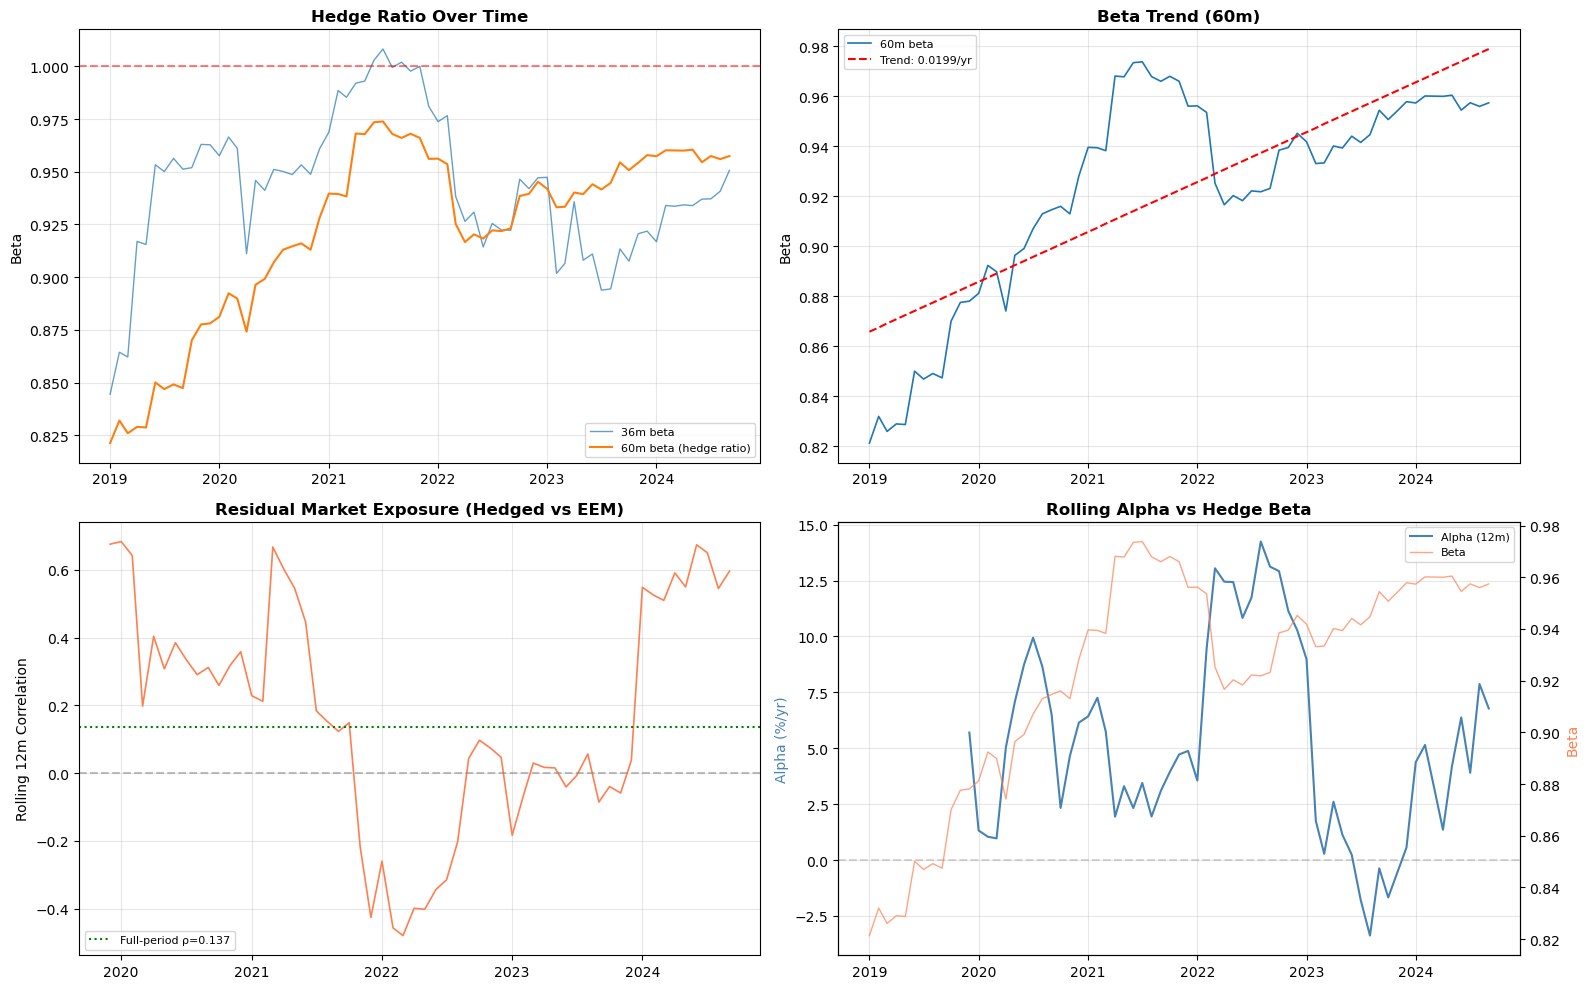

Hedge Ratio Summary:
  60m beta: mean=0.922, std=0.042
  Residual corr(hedged, EEM): 0.137 (target: 0)
  Residual beta: 0.049 (target: 0)


In [2]:
from src.residual_returns import estimate_rolling_beta

lo = hdf['A_long'].dropna()
eem = hdf['EEM_ret'].dropna()

beta_36 = estimate_rolling_beta(lo, eem, window=36, min_obs=18)
beta_60 = estimate_rolling_beta(lo, eem, window=60, min_obs=24)

b36_h = beta_36[beta_36.index >= HOLD_START].dropna()
b60_h = beta_60[beta_60.index >= HOLD_START].dropna()
beta_eem_h = hold['A_beta_eem'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Beta over time (both windows)
ax = axes[0, 0]
if len(b36_h) > 0:
    ax.plot(b36_h.index, b36_h.values, lw=1, alpha=0.7, label='36m beta')
ax.plot(beta_eem_h.index, beta_eem_h.values, lw=1.5, label='60m beta (hedge ratio)')
ax.axhline(y=1, color='red', ls='--', alpha=0.5)
ax.set_title('Hedge Ratio Over Time', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Beta')

# Beta trend
ax = axes[0, 1]
if len(beta_eem_h) > 5:
    x_num = np.arange(len(beta_eem_h))
    slope, intercept = np.polyfit(x_num, beta_eem_h.values, 1)
    trend = intercept + slope * x_num
    ax.plot(beta_eem_h.index, beta_eem_h.values, lw=1.2, label='60m beta')
    ax.plot(beta_eem_h.index, trend, lw=1.5, ls='--', color='red',
            label=f'Trend: {slope*12:.4f}/yr')
    ax.set_title('Beta Trend (60m)', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Beta')

# Residual market exposure after hedge
ax = axes[1, 0]
hedged = hold['A_hedged_eem'].dropna()
eem_hold = hold['EEM_ret'].dropna()
aligned = pd.concat([hedged.rename('hedged'), eem_hold.rename('eem')], axis=1).dropna()
roll_corr = aligned['hedged'].rolling(12).corr(aligned['eem'])
ax.plot(roll_corr.index, roll_corr.values, lw=1.2, color='coral')
ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
residual_corr = aligned['hedged'].corr(aligned['eem'])
ax.axhline(y=residual_corr, color='green', ls=':', label=f'Full-period ρ={residual_corr:.3f}')
ax.set_title('Residual Market Exposure (Hedged vs EEM)', fontweight='bold')
ax.set_ylabel('Rolling 12m Correlation'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Rolling alpha vs beta (dual axis)
ax = axes[1, 1]
roll_alpha = hedged.rolling(12).mean() * 12
ax.plot(roll_alpha.index, roll_alpha.values*100, lw=1.5, color='steelblue', label='Alpha (12m)')
ax.set_ylabel('Alpha (%/yr)', color='steelblue')
ax.axhline(y=0, color='gray', ls='--', alpha=0.3)
ax2 = ax.twinx()
ax2.plot(beta_eem_h.index, beta_eem_h.values, lw=1, color='coral', alpha=0.7, label='Beta')
ax2.set_ylabel('Beta', color='coral')
ax.set_title('Rolling Alpha vs Hedge Beta', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb10_hedge_dynamics.pdf', bbox_inches='tight')
plt.show()

print(f'Hedge Ratio Summary:')
print(f'  60m beta: mean={beta_eem_h.mean():.3f}, std={beta_eem_h.std():.3f}')
print(f'  Residual corr(hedged, EEM): {residual_corr:.3f} (target: 0)')
print(f'  Residual beta: {stats.linregress(aligned["eem"], aligned["hedged"])[0]:.3f} (target: 0)')

## 2. Jensen's Alpha & Appraisal Ratio (Hedged)

In [3]:
hedged_h = hold['A_hedged_eem'].dropna()
hedged_net = hedged_h - TC
eem_hold = hold['EEM_ret'].dropna()

aligned = pd.concat([hedged_net.rename('h'), eem_hold.rename('m')], axis=1).dropna()

slope, intercept, r_val, p_val, se = stats.linregress(aligned['m'], aligned['h'])
resid = aligned['h'].values - (intercept + slope * aligned['m'].values)
s_p = np.std(resid, ddof=1) * np.sqrt(12)

print('HEDGED PERFORMANCE MEASURES (Net @45bp)')
print('='*60)
print(f'  Jensen\'s Alpha:     {intercept*12:.2%}/yr (t={intercept/se:.2f}, p={p_val:.3f})')
print(f'  Residual Beta:       {slope:.3f} (should be ~0)')
print(f'  R²:                  {r_val**2:.4f} ({r_val**2*100:.2f}%)')
print(f'  Idiosyncratic Vol:   {s_p:.2%}')
print(f'  Appraisal Ratio:     {intercept*12/s_p:.3f}')
print(f'  Sharpe Ratio:        {ann_sharpe(hedged_net):.3f}')
print(f'  Treynor Measure:     {hedged_net.mean()*12/(slope if slope != 0 else 1):.4f}')
print(f'\n  The hedged Sharpe ≈ Appraisal Ratio when residual beta ≈ 0')
print(f'  (market-neutral condition: confirmed with R²={r_val**2:.4f})')

HEDGED PERFORMANCE MEASURES (Net @45bp)
  Jensen's Alpha:     4.16%/yr (t=0.08, p=0.262)
  Residual Beta:       0.049 (should be ~0)
  R²:                  0.0188 (1.88%)
  Idiosyncratic Vol:   6.60%
  Appraisal Ratio:     0.630
  Sharpe Ratio:        0.673
  Treynor Measure:     0.9082

  The hedged Sharpe ≈ Appraisal Ratio when residual beta ≈ 0
  (market-neutral condition: confirmed with R²=0.0188)


## 3. Alpha Time Series

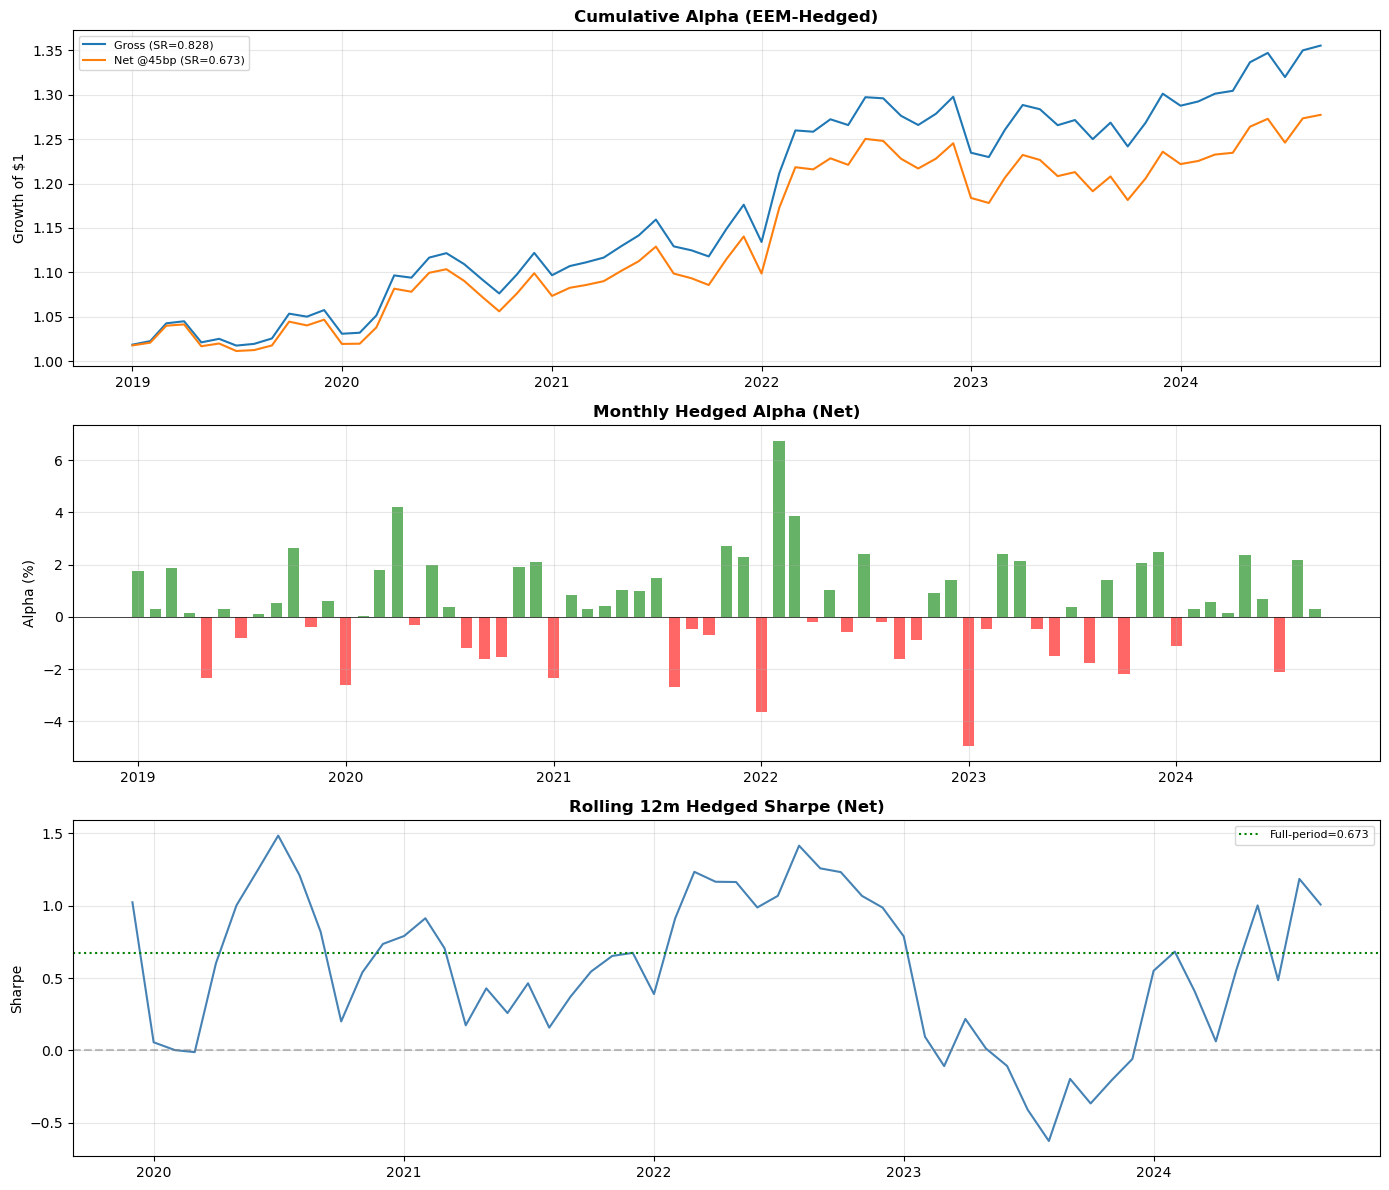

Alpha Summary:
  Mean monthly (net): 0.37% (4.48% ann.)
  Hedged Sharpe (net): 0.673
  Hit rate: 62.3%


In [4]:
alpha_gross = hold['A_hedged_eem'].dropna()
alpha_net = alpha_gross - TC

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Cumulative alpha
ax = axes[0]
cum_g = (1+alpha_gross).cumprod()
cum_n = (1+alpha_net).cumprod()
ax.plot(cum_g.index, cum_g.values, lw=1.5, label=f'Gross (SR={ann_sharpe(alpha_gross):.3f})')
ax.plot(cum_n.index, cum_n.values, lw=1.5, label=f'Net @45bp (SR={ann_sharpe(alpha_net):.3f})')
ax.set_title('Cumulative Alpha (EEM-Hedged)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

# Monthly bars
ax = axes[1]
colors = ['green' if x>0 else 'red' for x in alpha_net.values]
ax.bar(alpha_net.index, alpha_net.values*100, color=colors, alpha=0.6, width=20)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('Monthly Hedged Alpha (Net)', fontweight='bold')
ax.set_ylabel('Alpha (%)'); ax.grid(True, alpha=0.3)

# Rolling Sharpe
ax = axes[2]
roll_sr = alpha_net.rolling(12).apply(lambda x: x.mean()*12/(x.std()*np.sqrt(12)) if x.std()>0 else 0)
ax.plot(roll_sr.index, roll_sr.values, lw=1.5, color='steelblue')
ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
ax.axhline(y=ann_sharpe(alpha_net), color='green', ls=':', label=f'Full-period={ann_sharpe(alpha_net):.3f}')
ax.set_title('Rolling 12m Hedged Sharpe (Net)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Sharpe')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb10_alpha_timeseries.pdf', bbox_inches='tight')
plt.show()

print(f'Alpha Summary:')
print(f'  Mean monthly (net): {alpha_net.mean()*100:.2f}% ({alpha_net.mean()*12:.2%} ann.)')
print(f'  Hedged Sharpe (net): {ann_sharpe(alpha_net):.3f}')
print(f'  Hit rate: {(alpha_net>0).mean():.1%}')

## 4. Drawdown Attribution

Worst drawdown: -5.8% (from 2022-07 to 2023-02)

5 Worst Months:
  2023-01: alpha=-4.95%, worst industry=UTILS (-4.11%)
  2022-01: alpha=-3.65%, worst industry=TECNO (-13.36%)
  2021-08: alpha=-2.69%, worst industry=BMATR (-5.57%)
  2020-01: alpha=-2.61%, worst industry=RLEST (-15.18%)
  2019-05: alpha=-2.36%, worst industry=TECNO (-12.59%)


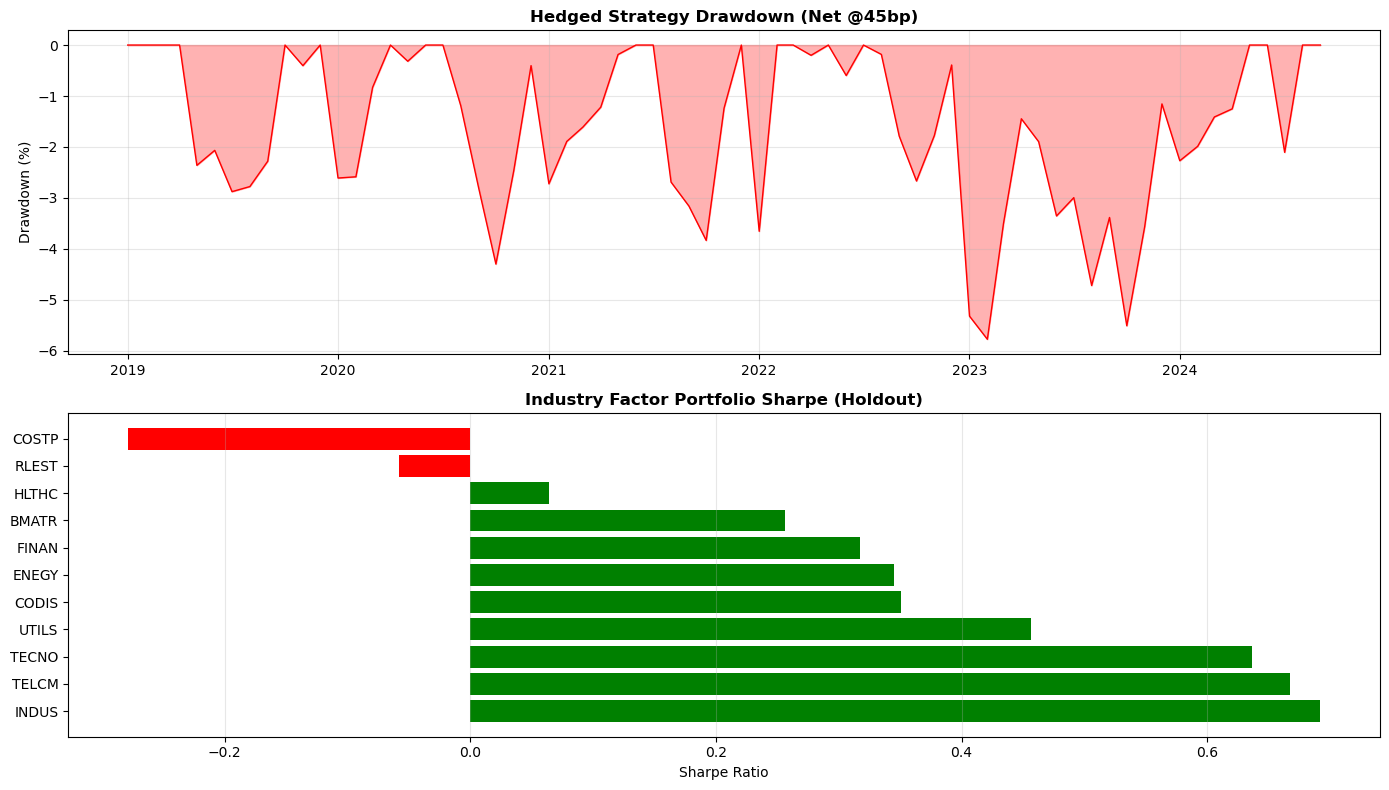

In [5]:
cum = (1 + alpha_net).cumprod()
dd = cum / cum.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.fill_between(dd.index, dd.values*100, 0, color='red', alpha=0.3)
ax.plot(dd.index, dd.values*100, lw=1, color='red')
ax.set_title('Hedged Strategy Drawdown (Net @45bp)', fontweight='bold')
ax.set_ylabel('Drawdown (%)'); ax.grid(True, alpha=0.3)

# Find worst drawdown periods
dd_min = dd.min()
dd_min_date = dd.idxmin()
# Find drawdown start
dd_start = dd[:dd_min_date]
dd_start = dd_start[dd_start == 0]
if len(dd_start) > 0:
    dd_start_date = dd_start.index[-1]
else:
    dd_start_date = dd.index[0]

print(f'Worst drawdown: {dd_min:.1%} (from {dd_start_date.strftime("%Y-%m")} to {dd_min_date.strftime("%Y-%m")})')

# Industry contribution during drawdowns
ax = axes[1]
ind_hold = ind_ret.reindex(hold.index).dropna(how='all')
# Show which industries drove the worst month
worst_months = alpha_net.nsmallest(5)
print(f'\n5 Worst Months:')
for dt, ret in worst_months.items():
    ind_vals = ind_hold.loc[dt] if dt in ind_hold.index else pd.Series()
    worst_ind = ind_vals.idxmin() if len(ind_vals) > 0 else 'N/A'
    print(f'  {dt.strftime("%Y-%m")}: alpha={ret:.2%}, worst industry={worst_ind} ({ind_vals.min():.2%})')

# Industry Sharpe
ind_sharpe = {c: ann_sharpe(ind_hold[c]) for c in industries}
sorted_ind = sorted(ind_sharpe.items(), key=lambda x: x[1], reverse=True)
ax.barh([x[0] for x in sorted_ind], [x[1] for x in sorted_ind],
        color=['green' if x[1]>0 else 'red' for x in sorted_ind])
ax.set_title('Industry Factor Portfolio Sharpe (Holdout)', fontweight='bold')
ax.set_xlabel('Sharpe Ratio'); ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb10_drawdown.pdf', bbox_inches='tight')
plt.show()

## 5. Sub-Period Stability

ANNUAL HEDGED PERFORMANCE (Net @45bp)
      Ann Alpha  Sharpe  Hit Rate   Vol  Max DD   N
Year                                               
2019      0.047   1.023     0.750 0.046  -0.029  12
2020      0.050   0.736     0.583 0.069  -0.043  12
2021      0.038   0.674     0.667 0.057  -0.038  12
2022      0.092   0.987     0.500 0.094  -0.027  12
2023     -0.008  -0.060     0.500 0.080  -0.041  12
2024      0.034   0.924     0.778 0.049  -0.021   9

Positive alpha years: 5/6


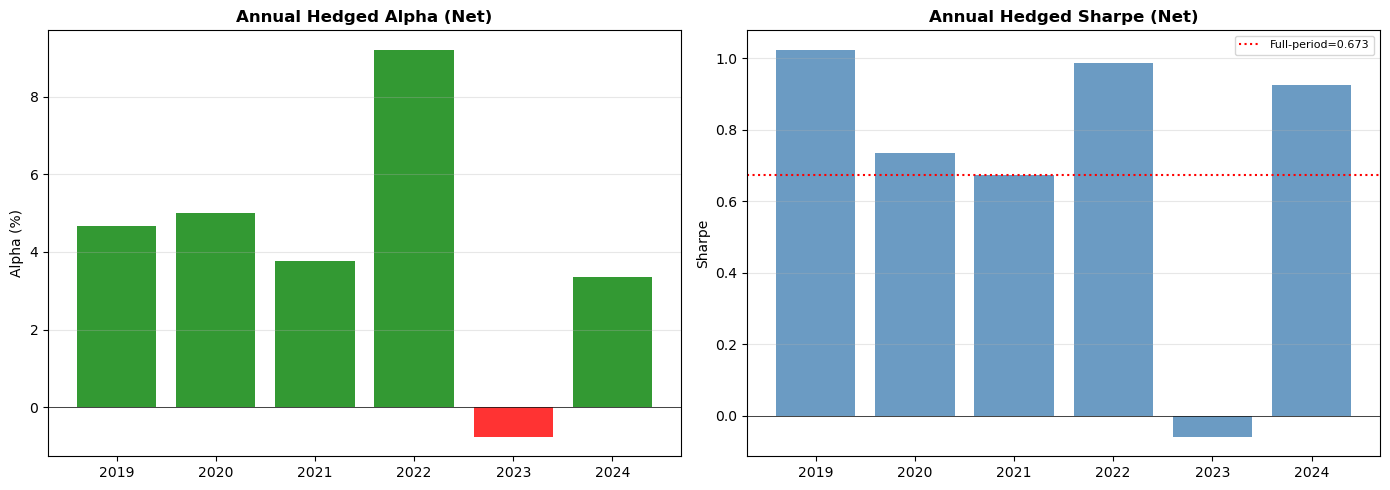

In [6]:
rows = []
for yr, g in alpha_net.groupby(alpha_net.index.year):
    rows.append({
        'Year': yr,
        'Ann Alpha': (1+g).prod()-1,
        'Sharpe': ann_sharpe(g) if len(g) >= 6 else np.nan,
        'Hit Rate': (g>0).mean(),
        'Vol': g.std()*np.sqrt(12),
        'Max DD': max_dd(g),
        'N': int(len(g)),
    })
annual = pd.DataFrame(rows).set_index('Year')

print('ANNUAL HEDGED PERFORMANCE (Net @45bp)')
print('='*80)
print(annual.to_string(float_format=lambda x: f'{x:.3f}' if abs(x)<2 else f'{x:.0f}'))

n_positive = (annual['Ann Alpha'] > 0).sum()
print(f'\nPositive alpha years: {n_positive}/{len(annual)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['green' if x>0 else 'red' for x in annual['Ann Alpha']]
ax.bar(annual.index.astype(int), annual['Ann Alpha']*100, color=colors, alpha=0.8)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('Annual Hedged Alpha (Net)', fontweight='bold')
ax.set_ylabel('Alpha (%)'); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(annual.index.astype(int), annual['Sharpe'].values, color='steelblue', alpha=0.8)
ax.axhline(y=0, color='k', lw=0.5)
ax.axhline(y=ann_sharpe(alpha_net), color='red', ls=':', label=f'Full-period={ann_sharpe(alpha_net):.3f}')
ax.set_title('Annual Hedged Sharpe (Net)', fontweight='bold')
ax.set_ylabel('Sharpe'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb10_subperiod.pdf', bbox_inches='tight')
plt.show()

## 6. Comprehensive Summary

In [7]:
lo = hold['A_long'].dropna()
lo_net = lo - TC
hd = hold['A_hedged_eem'].dropna()
hd_net = hd - TC
eem_h = hold['EEM_ret'].dropna()

aligned_ir = pd.concat([lo_net.rename('s'), eem_h.rename('b')], axis=1).dropna()
excess_ir = aligned_ir['s'] - aligned_ir['b']

summary = pd.DataFrame([{
    'LO Gross Sharpe': ann_sharpe(lo),
    'LO Net Sharpe': ann_sharpe(lo_net),
    'LO Ann Ret (net)': lo_net.mean()*12,
    'LO MaxDD': max_dd(lo),
    'Hedged Gross Sharpe': ann_sharpe(hd),
    'Hedged Net Sharpe': ann_sharpe(hd_net),
    'Hedged Alpha (net)': hd_net.mean()*12,
    'Hedged MaxDD': max_dd(hd),
    'IR vs EEM': excess_ir.mean()*12/(excess_ir.std()*np.sqrt(12)),
    'TE': excess_ir.std()*np.sqrt(12),
    'Avg Beta': beta_eem_h.mean(),
    'Residual Corr': residual_corr,
}], index=['All6-EW + TO_MVO'])

print('COMPREHENSIVE PERFORMANCE SUMMARY')
print('='*100)
print(summary.T.to_string(float_format=lambda x: f'{x:.3f}' if abs(x)<2 else f'{x:.1%}'))

summary.to_csv(f'{OUTPUT_DIR}/csv/nb10_performance_summary.csv')
print(f'\nSaved to {OUTPUT_DIR}/csv/nb10_performance_summary.csv')

COMPREHENSIVE PERFORMANCE SUMMARY
                     All6-EW + TO_MVO
LO Gross Sharpe                 0.514
LO Net Sharpe                   0.458
LO Ann Ret (net)                0.085
LO MaxDD                       -0.274
Hedged Gross Sharpe             0.828
Hedged Net Sharpe               0.673
Hedged Alpha (net)              0.045
Hedged MaxDD                   -0.052
IR vs EEM                       0.598
TE                              0.065
Avg Beta                        0.922
Residual Corr                   0.137

Saved to ../output/csv/nb10_performance_summary.csv
